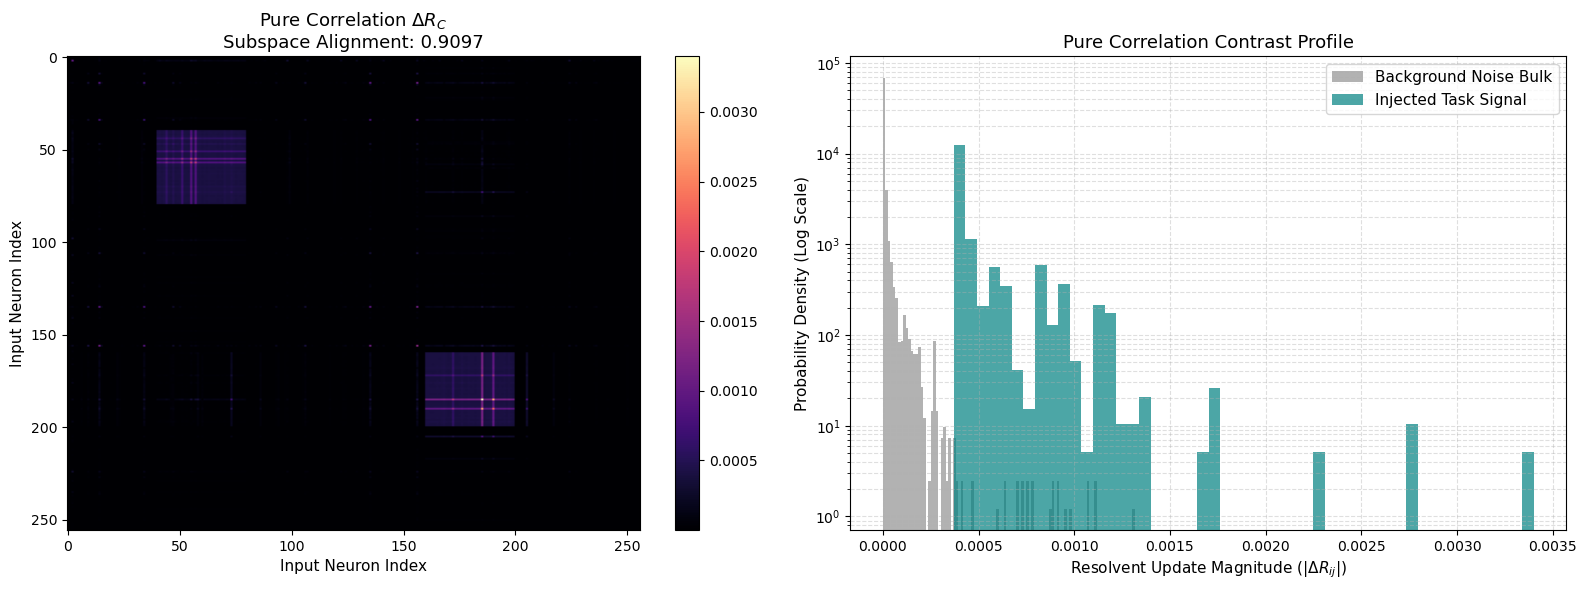

In [9]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP & TAMED INITIALIZATION
# ==========================================
M, N = 256, 256
alpha = 1.2
g = 1.0
I_space = np.eye(N)  # Pure NxN square correlation space

# Calculate standard heavy-tailed scaling
scale = g / (2 * N) ** (1 / alpha)

# Generate raw Levy weights
np.random.seed(42)
raw_W = stats.levy_stable.rvs(alpha, 0, scale=scale, size=(M, N), random_state=42)

# Apply the mathematical firewall (C=15) to tame finite-size black swans
cutoff_bound = 10.0 * scale * (N ** (1 / alpha))
W0 = np.clip(raw_W, -cutoff_bound, cutoff_bound)

# ==========================================
# 2. INJECT PURE CORRELATION COMMUNITIES
# ==========================================
# Since we are evaluating W^T * W, our signal must live in the NxN input correlation space
dW = np.zeros((M, N))
block_mask_W = np.zeros((M, N), dtype=bool)

# Inject structural community blocks into the weight matrix
block_mask_W[40:80, 40:80] = True
block_mask_W[160:200, 160:200] = True
dW[block_mask_W] = 0.8 * g

# Construct standard correlation updates
C0 = W0.T @ W0
C_perturbed = (W0 + dW).T @ (W0 + dW)
dC_true = C_perturbed - C0

# Create a ground truth mask for the NxN correlation space to validate metrics
correlation_mask = np.zeros((N, N), dtype=bool)
correlation_mask[40:80, 40:80] = True
correlation_mask[160:200, 160:200] = True

# ==========================================
# 3. DYNAMIC CORRELATION SPECTRAL CALIBRATION
# ==========================================
# Compute eigenvalues of the pure correlation matrix C0
evals = np.linalg.eigvalsh(C0)
lambda_max = evals[-1]

# Apply your winning calibration parameters directly to the correlation spectrum
E = 1.50 * lambda_max   # Push E 50% past the correlation horizon
eta = 0.20 * lambda_max # Broadening regularizer matching the scale

z = E + 1j * eta

# ==========================================
# 4. PURE CORRELATION RESOLVENT COMPUTATION
# ==========================================
R_C0 = np.linalg.inv(z * I_space - C0)
R_C = np.linalg.inv(z * I_space - C_perturbed)
delta_RC = R_C - R_C0

# Extract the pristine interaction mapping
dR_map = np.abs(delta_RC)

# ==========================================
# 5. VALIDATION METRICS
# ==========================================
# Compute the Subspace Alignment Score (Top 2 Singular Vectors)
U_true, _, _ = np.linalg.svd(dC_true, full_matrices=False)
V_true = U_true[:, :2]

U_res, _, _ = np.linalg.svd(dR_map, full_matrices=False)
V_res = U_res[:, :2]

alignment_score = np.trace(V_true.T @ V_res @ V_res.T @ V_true) / 2.0

# Isolate Signal vs Background entries for contrast analysis
signal_entries = dR_map[correlation_mask]
background_entries = dR_map[~correlation_mask]

# ==========================================
# 6. RENDER PURE DIAGNOSTIC PLOTS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot: The Functional Map captured by the Pure Correlation Resolvent
im = axes[0].imshow(dR_map, cmap='magma', aspect='auto')
axes[0].set_title(f"Pure Correlation $\\Delta R_C$\nSubspace Alignment: {alignment_score:.4f}", fontsize=13)
axes[0].set_xlabel("Input Neuron Index", fontsize=11)
axes[0].set_ylabel("Input Neuron Index", fontsize=11)
fig.colorbar(im, ax=axes[0])

# Right Plot: Topological Contrast Profile (Log Scale)
axes[1].hist(background_entries, bins=100, alpha=0.6, color='gray', density=True, label='Background Noise Bulk')
axes[1].hist(signal_entries, bins=50, alpha=0.7, color='teal', density=True, label='Injected Task Signal')
axes[1].set_title("Pure Correlation Contrast Profile", fontsize=13)
axes[1].set_xlabel("Resolvent Update Magnitude ($|\\Delta R_{ij}|$)", fontsize=11)
axes[1].set_ylabel("Probability Density (Log Scale)", fontsize=11)
axes[1].set_yscale('log')
axes[1].grid(True, which="both", ls="--", alpha=0.4)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

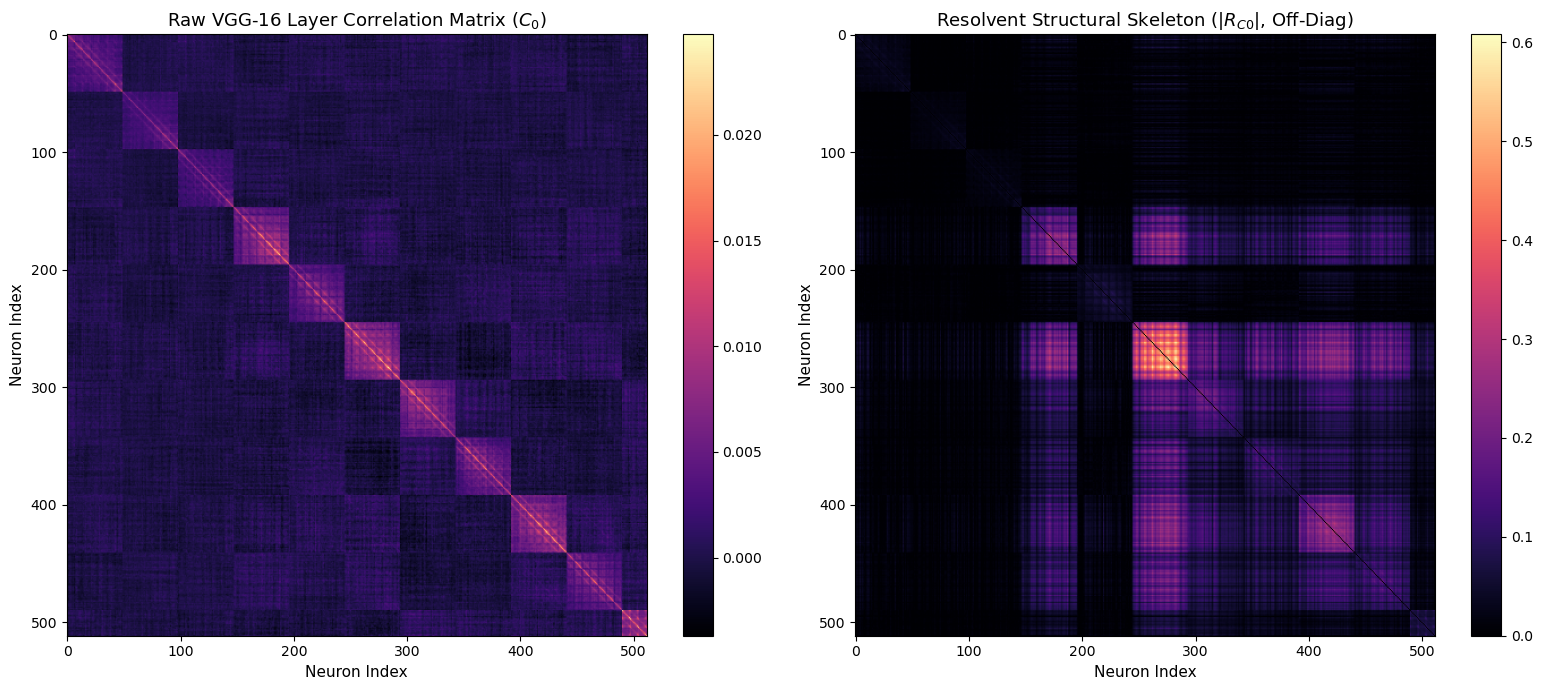

In [17]:
import torch
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD PRE-TRAINED VGG-16 WEIGHTS
# ==========================================
# Load the production-grade weights (organically optimized via ImageNet)
vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

# Extract the first massive fully connected layer (4096 x 4096)
W_full = vgg.classifier[0].weight.detach().cpu().numpy()

# Slice a manageable 512 x 512 block for rapid matrix inversion on CPU
N = 512
W0 = W_full[:N, :N]
I_space = np.eye(N)

# Compute the raw input correlation matrix
C0 = W0.T @ W0

# ==========================================
# 2. SHARP REAL-WORLD SPECTRAL CALIBRATION
# ==========================================
evals = np.linalg.eigvalsh(C0)
lambda_max = evals[-1]

# Deploy your close, sharp real-world microscope settings
E = 1.05 * lambda_max   # Hovering right over the active spectral edge
eta = 0.02 * lambda_max # High-resolution, low-dampening focus

z = E + 1j * eta

# ==========================================
# 3. COMPUTE THE ABSOLUTE RESOLVENT
# ==========================================
# Compute the absolute resolvent matrix
R_C0 = np.linalg.inv(z * I_space - C0)
R_magnitude = np.abs(R_C0)

# Zero out the strict diagonal elements so we only visualize
# the cross-correlation interaction pathways between different neurons
np.fill_diagonal(R_magnitude, 0)

# ==========================================
# 4. PLOT VGG-16'S STRUCTURAL SKELETON
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left Plot: Raw Correlation Space (Messy Bulk)
im0 = axes[0].imshow(C0, cmap='magma', aspect='auto')
axes[0].set_title("Raw VGG-16 Layer Correlation Matrix ($C_0$)", fontsize=13)
axes[0].set_xlabel("Neuron Index", fontsize=11)
axes[0].set_ylabel("Neuron Index", fontsize=11)
fig.colorbar(im0, ax=axes[0])

# Right Plot: The Resolvent Structural Skeleton (Filtered Hubs)
im1 = axes[1].imshow(R_magnitude, cmap='magma', aspect='auto')
axes[1].set_title("Resolvent Structural Skeleton ($|R_{C0}|$, Off-Diag)", fontsize=13)
axes[1].set_xlabel("Neuron Index", fontsize=11)
axes[1].set_ylabel("Neuron Index", fontsize=11)
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

Sampling Raw Alpha-Stable Weights...
Calculating Isotropic Singularity Map (Gaussian Mass Scaling)...


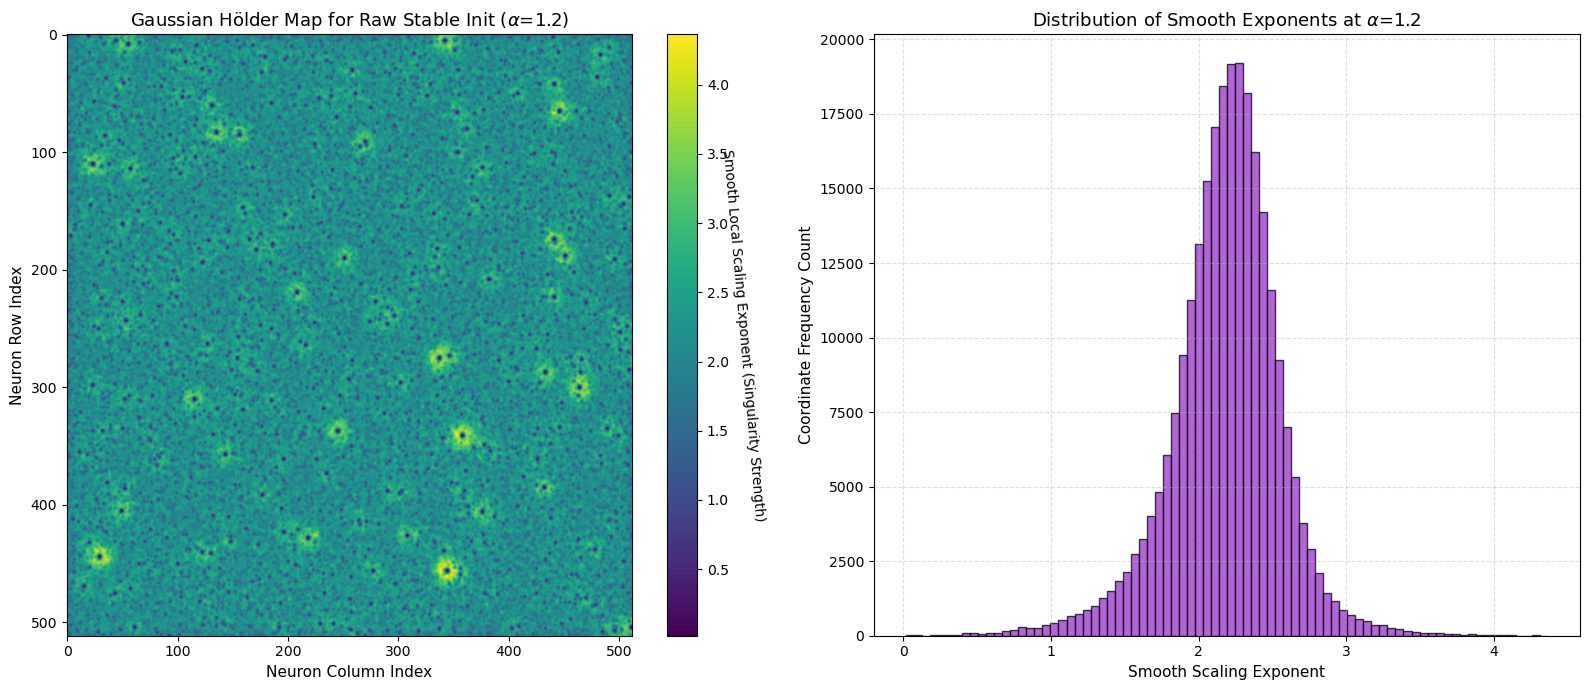

In [77]:
import torch
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# =====================================================================
# 1. DEPLOY YOUR HEAVY-TAILED INITIALIZER (ALPHA=1.2, G=1.0)
# =====================================================================
N = 512
alpha_val = 1.2
gain_val = 1.0
SEED = 42

n_eff = (N * N) ** 0.5
scale = gain_val / (2 * n_eff) ** (1 / alpha_val)

print("Sampling Raw Alpha-Stable Weights...")
samples = stats.levy_stable.rvs(
    alpha_val, 0, scale=scale, size=(N, N), random_state=SEED
)
# Treat the absolute weights as the underlying density/mass field
W0 = np.abs(samples)

# =====================================================================
# 2. SPATIAL HÖLDER SPECTRUM VIA DYNAMIC GAUSSIAN MASS SCALING
# =====================================================================
# Smoothly expanding scaling widths (Gaussian Standard Deviations)
sigmas = np.array([0.75, 1.25, 2.0, 3.0, 4.5, 6.0])
log_sigmas = np.log(sigmas)

holder_map = np.zeros_like(W0)

# Set an isolated context coordinate window size based on maximum scale scope
max_radius = int(3 * sigmas[-1])
padded_W = np.pad(W0, max_radius, mode='constant', constant_values=0)

# Generate relative coordinates for the Gaussian template patches beforehand
y_grid, x_grid = np.ogrid[-max_radius : max_radius + 1, -max_radius : max_radius + 1]
dist_squared = x_grid**2 + y_grid**2

print("Calculating Isotropic Singularity Map (Gaussian Mass Scaling)...")
for i in range(N):
    for j in range(N):
        pi, pj = i + max_radius, j + max_radius

        # Extract the continuous structural patch surrounding the coordinate
        patch = padded_W[pi - max_radius : pi + max_radius + 1,
                         pj - max_radius : pj + max_radius + 1]

        masses = []
        for sigma in sigmas:
            # Generate the radially symmetric Gaussian kernel smoothly decay envelope
            gaussian_kernel = np.exp(-dist_squared / (2.0 * sigma**2))

            # Compute the localized inner product mass parameter across scales
            total_mass = np.sum(patch * gaussian_kernel)
            masses.append(total_mass if total_mass > 1e-12 else 1e-12)

        # Linear regression in log-log space: log(Gaussian Mass) vs log(Sigma)
        log_masses = np.log(masses)
        slope, _ = np.polyfit(log_sigmas, log_masses, 1)

        # Save the smooth local exponent profile
        holder_map[i, j] = slope

# =====================================================================
# 3. PLOT SMOOTH GAUSSIAN MASS-SCALING HEATMAP
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left Plot: Refactored Isotropic Singularity Map
im0 = axes[0].imshow(holder_map, cmap='viridis', aspect='auto')
axes[0].set_title(f"Gaussian Hölder Map for Raw Stable Init ($\\alpha$={alpha_val})", fontsize=13)
axes[0].set_xlabel("Neuron Column Index", fontsize=11)
axes[0].set_ylabel("Neuron Row Index", fontsize=11)
cbar0 = fig.colorbar(im0, ax=axes[0])
cbar0.set_label("Smooth Local Scaling Exponent (Singularity Strength)", rotation=275, labelpad=15)

# Right Plot: Diagnostic Smooth Coordinate Distribution
axes[1].hist(holder_map.flatten(), bins=80, color='darkorchid', edgecolor='k', alpha=0.75)
axes[1].set_title(f"Distribution of Smooth Exponents at $\\alpha$={alpha_val}", fontsize=13)
axes[1].set_xlabel("Smooth Scaling Exponent", fontsize=11)
axes[1].set_ylabel("Coordinate Frequency Count", fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

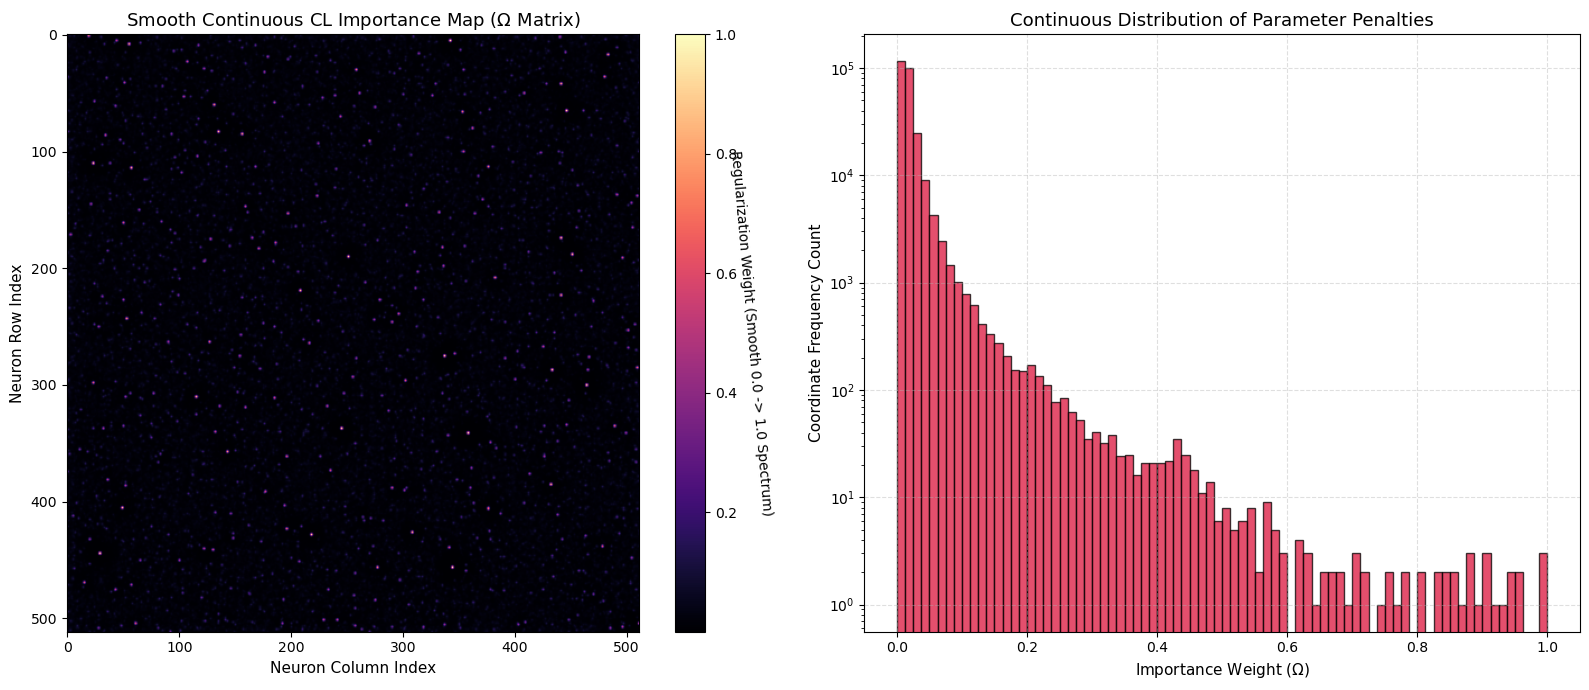

In [9]:
# =====================================================================
# 4. CONTINUOUS EXPONENTIAL GEOMETRIC TRANSFORMATION
# =====================================================================
# Shift and normalize the holder map to a standard 0.0 -> 1.0 baseline
h_min = np.min(holder_map)
h_max = np.max(holder_map)
h_normalized = (holder_map - h_min) / (h_max - h_min)

# Deploy a smooth exponential decay parameter
# High k concentrates weights heavily on the spiky hubs (low h)
# while allowing a smooth, continuous power-law decay into the bulk floor
k_steepness = 8.5
omega = np.exp(-k_steepness * h_normalized)

# =====================================================================
# 5. PLOT SMOOTH PATHWAY DIAGNOSTICS
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left Plot: Continuous Parameter Importance Profile
im0 = axes[0].imshow(omega, cmap='magma', aspect='auto')
axes[0].set_title("Smooth Continuous CL Importance Map ($\\Omega$ Matrix)", fontsize=13)
axes[0].set_xlabel("Neuron Column Index", fontsize=11)
axes[0].set_ylabel("Neuron Row Index", fontsize=11)
cbar0 = fig.colorbar(im0, ax=axes[0])
cbar0.set_label("Regularization Weight (Smooth 0.0 -> 1.0 Spectrum)", rotation=275, labelpad=15)

# Right Plot: Continuous Log Density Distribution
axes[1].hist(omega.flatten(), bins=80, color='crimson', edgecolor='k', alpha=0.75)
axes[1].set_title("Continuous Distribution of Parameter Penalties", fontsize=13)
axes[1].set_xlabel("Importance Weight ($\\Omega$)", fontsize=11)
axes[1].set_ylabel("Coordinate Frequency Count", fontsize=11)
axes[1].set_yscale('log')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [71]:
import os
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torchvision import datasets, transforms

sys.path.append(os.path.abspath(".."))
from src.utils import init_heavy_tailed, apply_heavy_tailed_init, set_seed
from src.architectures import GeneralMLP

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_gpu_mnist():
    """Loads full MNIST to GPU memory once."""
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    train_set = datasets.MNIST('../data', train=True, download=True, transform=transform)
    test_set = datasets.MNIST('../data', train=False, download=True, transform=transform)

    # Push everything to DEVICE immediately
    train_data = train_set.data.unsqueeze(1).float().to(DEVICE) / 255.0
    train_data = (train_data - 0.1307) / 0.3081
    train_labels = train_set.targets.to(DEVICE)

    test_data = test_set.data.unsqueeze(1).float().to(DEVICE) / 255.0
    test_data = (test_data - 0.1307) / 0.3081
    test_labels = test_set.targets.to(DEVICE)

    return (train_data, train_labels), (test_data, test_labels)

def generate_permutations(num_tasks, num_pixels=784, seed=42):
    """Generates clean pseudorandom domain permutations mapping each task stream."""
    rng = np.random.RandomState(seed)
    perms = [torch.arange(num_pixels).to(DEVICE)]  # Task 0 is standard un-permuted MNIST
    for _ in range(num_tasks - 1):
        perms.append(torch.from_numpy(rng.permutation(num_pixels)).to(DEVICE))
    return perms

class HolderRegularizer:
    def __init__(self, model, k_steepness=8.5, max_sigma=6.0):
        self.model = model
        self.k_steepness = k_steepness
        self.max_sigma = max_sigma

        # Consolidated online structures to eliminate multi-anchor conflicts
        self.consolidated_anchor = {}
        self.consolidated_mask = {}

    def calculate_task_importance(self, task_idx):
        """
        Diagnoses the local multifractal scaling topology of each weight matrix
        and updates a global, cumulative online importance mask.
        """
        # Set up standard scale horizons (Gaussian Sigmas)
        sigmas = torch.tensor([0.75, 1.25, 2.0, 3.0, 4.5, 6.0], device=next(self.model.parameters()).device)
        log_sigmas = torch.log(sigmas)

        # Set localized window boundary context
        max_radius = int(3 * self.max_sigma)
        kernel_dim = 2 * max_radius + 1

        # Pre-compute relative coordinates and squared distance matrices for the kernels
        y, x = torch.meshgrid(
            torch.arange(-max_radius, max_radius + 1, device=sigmas.device),
            torch.arange(-max_radius, max_radius + 1, device=sigmas.device),
            indexing="ij"
        )
        dist_squared = (x**2 + y**2).unsqueeze(0)  # Shape: [1, kernel_dim, kernel_dim]

        # Generate the stack of multi-scale Gaussian kernels: [num_scales, kernel_dim, kernel_dim]
        gaussian_kernels = torch.exp(-dist_squared / (2.0 * sigmas.view(-1, 1, 1)**2))

        for name, param in self.model.named_parameters():
            if "weight" in name and "classifier" not in name:
                W = param.detach()

                # Update the consolidated anchor to the most recent successful weight state
                self.consolidated_anchor[name] = W.clone()

                # Treat the absolute weight magnitudes as the underlying mass field
                mass_field = torch.abs(W)
                H, W_dim = mass_field.shape

                # Pad the tensor boundaries to safely pass the window envelope
                padded_mass = F.pad(mass_field, (max_radius, max_radius, max_radius, max_radius), mode="constant", value=0.0)

                # Unfold the padded array into localized operational patches
                patches = padded_mass.unfold(0, kernel_dim, 1).unfold(1, kernel_dim, 1)
                patches = patches.contiguous().view(H, W_dim, -1)

                # Flatten kernels for batch inner product calculation
                flat_kernels = gaussian_kernels.view(len(sigmas), -1)  # [num_scales, kernel_dim*kernel_dim]

                # Compute the total integrated mass across scales for all coordinates
                masses = torch.matmul(patches, flat_kernels.t())
                masses = torch.clamp(masses, min=1e-12)
                log_masses = torch.log(masses)

                # Execute vectorized linear regressions over log-space to extract slopes
                X = torch.stack([log_sigmas, torch.ones_like(log_sigmas)], dim=1)
                X_pseudo_inv = torch.linalg.pinv(X)  # [2, num_scales]

                # Extract slopes across every parameter coordinate
                holder_map = torch.matmul(log_masses, X_pseudo_inv[0])

                # --- Continuous Reshaping ---
                h_min = torch.min(holder_map)
                h_max = torch.max(holder_map)

                if h_max > h_min:
                    h_normalized = (holder_map - h_min) / (h_max - h_min)
                else:
                    h_normalized = torch.zeros_like(holder_map)

                # Generate the smooth continuous mask for the current task
                omega = torch.exp(-self.k_steepness * h_normalized)

                # --- Online Mask Consolidation ---
                if name not in self.consolidated_mask:
                    self.consolidated_mask[name] = omega.clone()
                else:
                    # Accumulate protection: once a hub is marked important by any task, it stays protected
                    self.consolidated_mask[name] = torch.max(self.consolidated_mask[name], omega)

    def compute_regularization_loss(self):
        """
        Streamlined Online EWC loop. Evaluates a single, non-conflicting
        quadratic penalty against the cumulative historical anchor configuration.
        """
        reg_loss = 0.0
        if not self.consolidated_anchor:
            return torch.tensor(0.0, device=next(self.model.parameters()).device)

        for name, param in self.model.named_parameters():
            if "weight" in name and "classifier" not in name:
                W_anchor = self.consolidated_anchor[name]
                omega_mask = self.consolidated_mask[name]

                # Quadratic parameter drift evaluated strictly against the most recent history
                parameter_drift = (param - W_anchor) ** 2

                # Accumulate the consolidated penalty
                reg_loss += torch.sum(omega_mask * parameter_drift)

        return reg_loss


class PowerGPM:
    def __init__(self, model, gamma=0.5, noise_cutoff=0.01):
        """
        PowerGPM: A Soft-Margin Gradient Projection Memory Backbone

        Args:
            model: The neural network instance.
            gamma: Exponent for the fractional power law soft-mask.
                   gamma = 1.0 -> Linear scale protection.
                   gamma -> 0.0 -> Approaches classical hard-binary GPM block.
            noise_cutoff: Normalized singular value threshold. Values below this
                          fraction of the maximum singular value drop cleanly to 0.0
                          to keep the background parameter bulk fully plastic.
        """
        self.model = model
        self.gamma = gamma
        self.noise_cutoff = noise_cutoff

        # Tracks the globally accumulated blocking subspace operator (Ω)
        self.consolidated_Omega = {}

        # Hook tracking structures
        self.hooks = []
        self.collected_activations = {}

    def _register_execution_hooks(self):
        self.hooks = []
        self.collected_activations = {}

        def make_hook(name):
            def hook(module, input_tensor, output_tensor):
                if name not in self.collected_activations:
                    self.collected_activations[name] = []
                # Capture incoming features entering the layer: shape [B, N_dim]
                self.collected_activations[name].append(input_tensor[0].detach())
            return hook

        for name, module in self.model.named_modules():
            if isinstance(module, torch.nn.Linear):
                h = module.register_forward_hook(make_hook(name))
                self.hooks.append(h)

    def _remove_execution_hooks(self):
        for h in self.hooks:
            h.remove()
        self.hooks = []

    def capture_and_update_topology(self, train_x, current_perm, input_size, batch_size=128, device="cuda"):
        """
        Gathers layer activations, projects them into the historical null-space,
        extracts coordinate-free directions via SVD, applies a power law soft mask,
        and updates the global blocking operator orthogonally.
        """
        self.model.eval()
        self._register_execution_hooks()

        num_samples = train_x.size(0)

        # 1. Gather raw task activations
        with torch.no_grad():
            for i in range(0, num_samples, batch_size):
                x_batch = train_x[i : i + batch_size].view(-1, input_size).to(device)
                x_batch = x_batch[:, current_perm]
                _ = self.model(x_batch)

        self._remove_execution_hooks()

        # 2. Process spaces via Orthonormal SVD Power Law Filtering
        for name, param in self.model.named_parameters():
            module_name = name.replace(".weight", "")
            if module_name in self.collected_activations and "classifier" not in name:

                # Stack samples along batch dimension: [Total_Samples, N_dim]
                act_matrix = torch.cat(self.collected_activations[module_name], dim=0)
                R = act_matrix.t()  # Rotate to classic layout: [N_dim, Total_Samples]
                N_dim = R.shape[0]

                # 3. Apply the current null-space projector to isolate raw innovation residual
                if name in self.consolidated_Omega:
                    I_mask = torch.eye(N_dim, device=device)
                    P_hist = I_mask - self.consolidated_Omega[name]
                    R_residual = torch.matmul(P_hist, R)
                else:
                    R_residual = R

                total_variance = torch.sum(R_residual ** 2)
                if total_variance < 1e-12:
                    continue

                # 4. Compute Orthonormal SVD directly on the residual activation array
                # U shape: [N_dim, N_dim], S shape: [N_dim]
                U, S, _ = torch.linalg.svd(R_residual, full_matrices=False)

                sigma_max = S[0]
                if sigma_max < 1e-9:
                    continue

                # --- DIAGNOSTIC: COMPUTE AND SAVE RANK-IPR GEOMETRY ---
                if not hasattr(self, 'diagnostic_ipr_records'):
                    self.diagnostic_ipr_records = {}

                # Compute IPR across the singular vectors: sum(u_i^4) along the node dimension
                # U shape: [N_dim, N_dim] -> sum along dim=0 yields an [N_dim] array ordered by rank
                vector_ipr = torch.sum(U**4, dim=0).cpu().numpy()
                singular_values_np = S.cpu().numpy()

                if name not in self.diagnostic_ipr_records:
                    self.diagnostic_ipr_records[name] = []

                self.diagnostic_ipr_records[name].append({
                    'task': current_perm, # Tracks the current evaluation checkpoint
                    'ipr': vector_ipr,
                    'singular_values': singular_values_np
                })

                sigma_max = S[0]
                if sigma_max < 1e-9:
                    continue

                # 5. Execute the Power Law Soft-Mask Filtering Pass
                # Max-normalize the singular values to establish a safe scale bounds [0.0, 1.0]
                S_norm = S / sigma_max

                # Apply the continuous power law compression to lift intermediate halos
                mu_clean = torch.pow(S_norm, self.gamma)

                # Clamp values below our structural noise floor cutoff straight to 0.0
                # This explicitly preserves background bulk parameter plasticity
                mu_clean[S_norm < self.noise_cutoff] = 0.0

                # 6. Reconstruct the symmetric innovation operator in the rotated basis
                M_hat = U @ torch.diag(mu_clean) @ U.t()

                # 7. Complete an orthogonal addition to update the global space
                if name not in self.consolidated_Omega:
                    self.consolidated_Omega[name] = M_hat
                else:
                    # Addition is mathematically sound because R_residual was pre-filtered
                    # by P_hist, ensuring M_hat belongs to the null-space of consolidated_Omega
                    self.consolidated_Omega[name] = self.consolidated_Omega[name] + M_hat

                    # Enforce rigid ceiling limits against minor numerical precision drift
                    self.consolidated_Omega[name] = torch.clamp(self.consolidated_Omega[name], max=1.0)

        self.collected_activations = {}

    def project_gradients(self):
        """Filters weight gradients using the continuous null-space complement matrix."""
        for name, param in self.model.named_parameters():
            if "weight" in name and "classifier" not in name:
                if name in self.consolidated_Omega and param.grad is not None:
                    N_dim = self.consolidated_Omega[name].shape[0]
                    I = torch.eye(N_dim, device=param.device)

                    # Compute the continuous projection complement matrix: P = I - Ω
                    P = I - self.consolidated_Omega[name]

                    # Filter the parameter gradient tensor inline before the optimizer steps
                    param.grad.data = torch.matmul(param.grad.data, P)

In [70]:
import torch.optim as optim
import numpy as np

# ==========================================
# 1. HARDWARE CONFIGURATION & HYPERPARAMETERS
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing experiment on: {DEVICE}")

# Experiment Parameters
NUM_TASKS = 3
EPOCHS_PER_TASK = 10
BATCH_SIZE = 128
LR = 0.1
LAMBDA_REG = 10.0  # Consolidation penalty weight
SEED = 42


# Network Architecture
INPUT_SIZE = 784
HIDDEN_SIZE = 512
NUM_CLASSES = 10
DEPTH = 2

# Heavy-Tailed Configurations
ALPHA = 1.2
G_PARAM = 1.0

# Setup deterministic state
set_seed(SEED)

# ==========================================
# 2. DATA PREPARATION & PERMUTATION STREAM
# ==========================================
print("Loading data stream and generating task domains...")
(train_x, train_y), (test_x, test_y) = get_gpu_mnist()
task_permutations = generate_permutations(
    num_tasks=NUM_TASKS, num_pixels=INPUT_SIZE, seed=SEED
)

# ==========================================
# 3. INITIALIZE MODELS AND STRUCTURAL MICROSCOPE
# ==========================================
# Instantiate our baseline network
model = GeneralMLP(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_classes=NUM_CLASSES,
    depth=DEPTH,
    activation_name="tanh",
    bias=False,
).to(DEVICE)

# Apply the mathematical firewall right at the root initialization
model = apply_heavy_tailed_init(
    model,
    alpha=ALPHA,
    g=G_PARAM,
    seed=SEED,
    cutoff_bound=None,
)

# Attach your winning resolvent probe settings (Precision Focus)
reg_engine = PowerGPM(model, gamma=0.6, noise_cutoff=0.03)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR)

# Matrix to track historical metrics for validation
accuracy_matrix = np.zeros((NUM_TASKS, NUM_TASKS))

# ==========================================
# 4. CORE CONTINUAL LEARNING LOOP
# ==========================================
for current_task in range(NUM_TASKS):
    print(f"\n--- Starting Task {current_task} ---")
    current_perm = task_permutations[current_task]

    # Simple explicit batch loader out of GPU memory
    num_samples = train_x.size(0)

    model.train()
    for epoch in range(EPOCHS_PER_TASK):
        # Shuffle indices every epoch
        shuffled_indices = torch.randperm(num_samples, device=DEVICE)
        epoch_loss = 0.0

        for i in range(0, num_samples, BATCH_SIZE):
            indices = shuffled_indices[i : i + BATCH_SIZE]
            x_batch = train_x[indices].view(-1, INPUT_SIZE)
            y_batch = train_y[indices]

            # Apply the domain permutation mapping for this specific task
            x_batch = x_batch[:, current_perm]

            optimizer.zero_grad()
            outputs = model(x_batch)

            # Pure task classification loss - no soft regularizer overhead
            loss = criterion(outputs, y_batch)
            loss.backward()

            # --- Resolvent Subspace Projection Step ---
            # Filter conflicting gradient vectors only if we have historic tasks to protect
            if current_task > 0:
                # pass
                reg_engine.project_gradients()

            optimizer.step()

            epoch_loss += loss.item() * len(indices)

        print(
            f"Epoch {epoch + 1}/{EPOCHS_PER_TASK} | Total Loss: {epoch_loss / num_samples:.4f}"
        )

    # ==========================================
    # 5. POST-TASK SPECTRUM SNAPSHOT & EXPANSION
    # ==========================================
    # Task boundary reached: lock in anchor coordinates and deploy the resolvent filter
    print(f"Freezing Task {current_task} structural topology via resolvent map...")
    reg_engine.capture_and_update_topology(
        train_x=train_x,
        current_perm=current_perm,
        input_size=INPUT_SIZE,
        batch_size=256,  # <-- Change this to adjust calculation footprint vs speed
        device=DEVICE
    )

    # ==========================================
    # 6. COMPREHENSIVE SUB-NETWORK EVALUATION
    # ==========================================
    model.eval()
    with torch.no_grad():
        for evaluation_task in range(current_task + 1):
            eval_perm = task_permutations[evaluation_task]
            correct = 0
            total = test_x.size(0)

            for i in range(0, total, BATCH_SIZE):
                x_test_batch = test_x[i : i + BATCH_SIZE].view(-1, INPUT_SIZE)
                y_test_batch = test_y[i : i + BATCH_SIZE]

                # Transform inputs back into historical task domains
                x_test_batch = x_test_batch[:, eval_perm]

                test_outputs = model(x_test_batch)
                preds = test_outputs.argmax(dim=1)
                correct += (preds == y_test_batch).sum().item()

            acc = correct / total
            accuracy_matrix[current_task, evaluation_task] = acc
            print(f"  -> Accuracy on Task {evaluation_task}: {acc * 100:.2f}%")

# ==========================================
# 7. FINAL DIAGNOSTIC SIGNATURE
# ==========================================
print("\n--- Final Matrix Results ---")
print(
    "Rows represent the current training step, columns indicate performance on past tasks:"
)
print(accuracy_matrix[:NUM_TASKS, :NUM_TASKS])

Executing experiment on: cuda
Loading data stream and generating task domains...
Applying HT Init: alpha=1.2, g=1.0, seed=42

--- Starting Task 0 ---
Epoch 1/10 | Total Loss: 0.3756
Epoch 2/10 | Total Loss: 0.1370
Epoch 3/10 | Total Loss: 0.0941
Epoch 4/10 | Total Loss: 0.0705
Epoch 5/10 | Total Loss: 0.0541
Epoch 6/10 | Total Loss: 0.0423
Epoch 7/10 | Total Loss: 0.0342
Epoch 8/10 | Total Loss: 0.0256
Epoch 9/10 | Total Loss: 0.0203
Epoch 10/10 | Total Loss: 0.0158
Freezing Task 0 structural topology via resolvent map...
  -> Accuracy on Task 0: 97.92%

--- Starting Task 1 ---
Epoch 1/10 | Total Loss: 0.3906
Epoch 2/10 | Total Loss: 0.1238
Epoch 3/10 | Total Loss: 0.0844
Epoch 4/10 | Total Loss: 0.0627
Epoch 5/10 | Total Loss: 0.0478
Epoch 6/10 | Total Loss: 0.0362
Epoch 7/10 | Total Loss: 0.0278
Epoch 8/10 | Total Loss: 0.0214
Epoch 9/10 | Total Loss: 0.0164
Epoch 10/10 | Total Loss: 0.0125
Freezing Task 1 structural topology via resolvent map...
  -> Accuracy on Task 0: 93.54%
  -> 

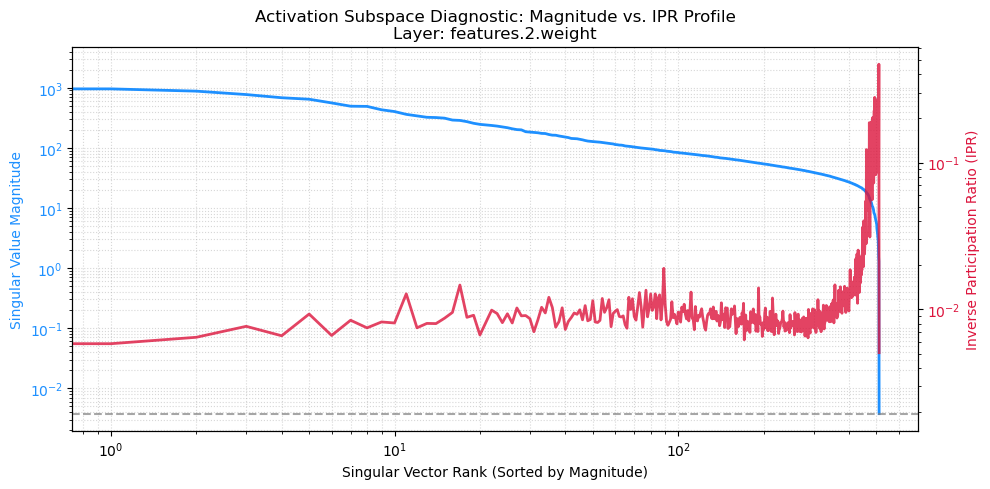

In [78]:
import matplotlib.pyplot as plt
import numpy as np

def plot_layer_mag_ipr(projector_instance, layer_name, task_index=0):
    """
    Plots a dual-axis Rank vs. Magnitude and Rank vs. IPR curve for a specific layer
    and task checkpoint from the saved diagnostic records.
    """
    if not hasattr(projector_instance, 'diagnostic_ipr_records'):
        print("Error: No diagnostic records found. Run the update loop first.")
        return

    if layer_name not in projector_instance.diagnostic_ipr_records:
        print(f"Error: Layer '{layer_name}' not found in records.")
        return

    # Extract the records for the specified task checkpoint
    records = projector_instance.diagnostic_ipr_records[layer_name]
    target_record = None
    for r in records:
        # Check if tracking identifier matches
        if isinstance(r['task'], int) and r['task'] == task_index:
            target_record = r
            break
        elif isinstance(r['task'], np.ndarray) or hasattr(r['task'], '__len__'):
            # Fallback if current_perm is passed as the raw array/list identifier
            target_record = r # Grab the latest match if matching complex objects

    if target_record is None:
        target_record = records[-1] # Default to the most recent run if index mismatch

    s_vals = target_record['singular_values']
    ipr_vals = target_record['ipr']
    ranks = np.arange(len(s_vals))

    # Setup the plot environment
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Left Axis: Singular Value Magnitude
    color = 'dodgerblue'
    ax1.set_xlabel('Singular Vector Rank (Sorted by Magnitude)', fontsize=10)
    ax1.set_ylabel('Singular Value Magnitude', color=color, fontsize=10)
    ax1.plot(ranks, s_vals, color=color, linewidth=2, label='Singular Values')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_yscale('log')
    ax1.set_xscale('log')
    ax1.grid(True, which="both", linestyle=":", alpha=0.5)

    # Right Axis: Inverse Participation Ratio (IPR)
    ax2 = ax1.twinx()
    color = 'crimson'
    ax2.set_ylabel('Inverse Participation Ratio (IPR)', color=color, fontsize=10)
    ax2.plot(ranks, ipr_vals, color=color, linewidth=2, alpha=0.8, label='IPR Matrix')
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.set_yscale('log')
    ax2.set_xscale('log')

    # Highlight the absolute minimum limit boundary
    ax2.axhline(y=1.0/len(s_vals), color='gray', linestyle='--', alpha=0.7,
                label=f'Theoretical Minimum (1/{len(s_vals)})')

    plt.title(f"Activation Subspace Diagnostic: Magnitude vs. IPR Profile\nLayer: {layer_name}", fontsize=12)
    fig.tight_layout()
    plt.show()

# --- Example Usage Post-Training ---
plot_layer_mag_ipr(reg_engine, layer_name='features.2.weight')

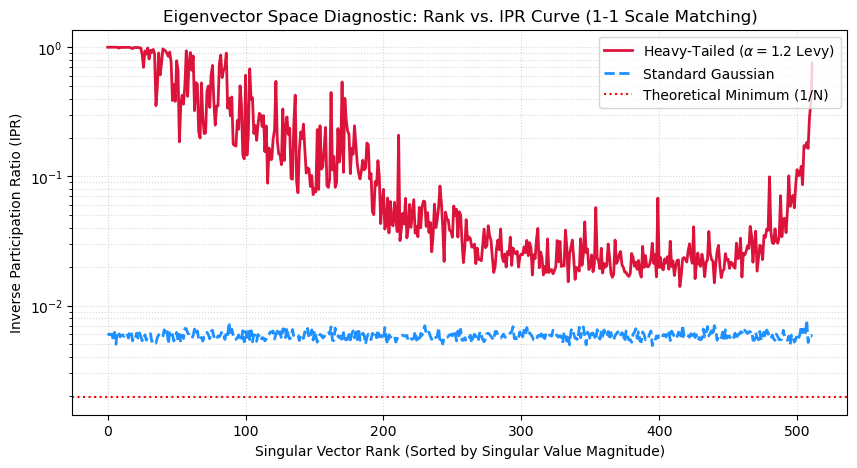

In [76]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# --- Execution Parameters ---
N_dim = 512
samples_count = 2000

# Allocate matching PyTorch tensors
tensor_ht = torch.empty(N_dim, samples_count)
tensor_gaussian = torch.empty(N_dim, samples_count)

# 1. Initialize matrices using your exact initialization schema
init_heavy_tailed(tensor_ht, alpha=1.2, g=1.0, seed=0)
torch.nn.init.normal_(tensor_gaussian, mean=0.0, std=1.0)

# Convert to numpy arrays for SVD processing
matrix_ht = tensor_ht.numpy()
matrix_gaussian = tensor_gaussian.numpy()

# 2. Extract Singular Vectors (U-basis) via SVD
U_ht, S_ht, _ = np.linalg.svd(matrix_ht, full_matrices=False)
U_gauss, S_gauss, _ = np.linalg.svd(matrix_gaussian, full_matrices=False)

# 3. Compute the Inverse Participation Ratio (IPR = sum(u_i^4)) for every axis
ipr_ht = np.sum(U_ht**4, axis=0)
ipr_gauss = np.sum(U_gauss**4, axis=0)

# 4. Plot the resulting Rank-IPR Curve
plt.figure(figsize=(10, 5))
plt.plot(ipr_ht, color="crimson", label=r"Heavy-Tailed ($\alpha=1.2$ Levy)", linewidth=2)
plt.plot(ipr_gauss, color="dodgerblue", label="Standard Gaussian", linestyle="--", linewidth=2)

# Theoretical Minimum line for a perfectly delocalized frame (1/N)
plt.axhline(y=1.0/N_dim, color="red", linestyle=":", label="Theoretical Minimum (1/N)")

plt.title("Eigenvector Space Diagnostic: Rank vs. IPR Curve (1-1 Scale Matching)", fontsize=12)
plt.xlabel("Singular Vector Rank (Sorted by Singular Value Magnitude)", fontsize=10)
plt.ylabel("Inverse Participation Ratio (IPR)", fontsize=10)
plt.yscale("log")  # Log scale highlights the extreme split at the apex tail
plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.legend(fontsize=10)

plt.show()